In [1]:
! pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 10.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.1 MB/s eta 0:00:0000:01


In [3]:
from fastai.vision.all import *
from fastbook import *

## Image Classification

### 3 or more categories

We've already seen how to approach binary classification problems where the model is supposed to label the input as either one class or another. The next step we'll tackle here is doing that when there are more than 2 possible classes. In other words, label the input data as one of three or more possible classes.

In [4]:
path = untar_data(URLs.PETS)
path

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:16&lt;00:00]</div>

Path('/root/.fastai/data/oxford-iiit-pet')

Centralize path traversal to the dataset location.

In [6]:
Path.BASE_PATH = path
Path.BASE_PATH

Path('.')

In [7]:
path.ls()

[Path('images'), Path('annotations')]

The `annotations/` folder contains location data, which is not relevant here. We care about classifying the images based on their visual features.

In [10]:
(path/'images').ls()

(#7393) [Path('images/beagle_115.jpg'), Path('images/boxer_18.jpg'), Path('images/Maine_Coon_157.jpg'), Path('images/scottish_terrier_28.jpg'), Path('images/english_setter_6.jpg'), Path('images/american_pit_bull_terrier_79.jpg'), Path('images/boxer_128.jpg'), Path('images/Persian_265.jpg'), Path('images/Maine_Coon_182.jpg'), Path('images/keeshond_89.jpg'), Path('images/chihuahua_82.jpg'), Path('images/basset_hound_5.jpg'), Path('images/english_cocker_spaniel_144.jpg'), Path('images/scottish_terrier_108.jpg'), Path('images/British_Shorthair_116.jpg'), Path('images/boxer_10.jpg'), Path('images/basset_hound_194.jpg'), Path('images/beagle_85.jpg'), Path('images/japanese_chin_87.jpg'), Path('images/pug_40.jpg'), Path('images/chihuahua_199.jpg'), Path('images/english_setter_152.jpg'), Path('images/Bengal_98.jpg'), Path('images/chihuahua_174.jpg'), Path('images/leonberger_166.jpg'), Path('images/german_shorthaired_68.jpg'), Path('images/miniature_pinscher_27.jpg'), Path('images/Ragdoll_257.jp

The file names contain the label and an index of that file in the list for the breed. So we need to extract that label carefully.

In [16]:
fname = (path/'images').ls()[0]
re.findall(r'(.+)_\d+\.jpg', fname.name)

['beagle']

Works well enough. Now we'll apply it to the full dataset. We'll use `RegexLabeller` in a `DataBlock` because `DataBlock` is our go-to method for organizing the data into data loaders.

In [37]:
pets = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=using_attr(RegexLabeller(r'(.+)_\d+\.jpg'), 'name'),
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
)
pets

In [38]:
pets.dataloaders(path/'images').show_batch(nrows=1, ncols=3)

RuntimeError: Error when trying to collate the data into batches with fa_collate, at least two tensors in the batch are not the same size.

Mismatch found on axis 0 of the batch and is of type `TensorImage`:
	Item at index 0 has shape: torch.Size([3, 335, 500])
	Item at index 1 has shape: torch.Size([3, 375, 500])

Please include a transform in `after_item` that ensures all data of type TensorImage is the same size

That error message highlights the importance of transforming all the input data into the same size!

#### Presizing

The idea here is to perform different manipulation operations that will generate the final set of images that constitute the training and validation data. Of course the data must be the same size so they can all work well with the tensor format used by the model. In this process, we have an incentive to:
1. minimize the augmentation operations performed on the images, because that reduces the computational effort required to generate the dataset while also minimizing the number of lossy or pixel-destructive operations performed on the original data
2. perform these operations in groups/batches to take advantage of the GPU's parallelism

As mentioned earlier, a lot of the augmentation operations can destroy the details of some pixels (eg skew) or create empty zones where nothing is happening (eg rotation). So performing the augmentation operations after resizing to the final size would leave no way to do anything about these losses. One solution is to resize to an initial larger size, apply the transformations, then resize to the final smaller size.

In this fastai this is done by applying the initial resize in the CPU using `item_tfms`, then performing the augmentation and final resize operations in batches using `batch_tfms`. The initial resize is done image-by-image on the CPU because the GPU is where the images need to be the same size. Also note that the augmentations are not performed on the validation set, only the resize to the final size.

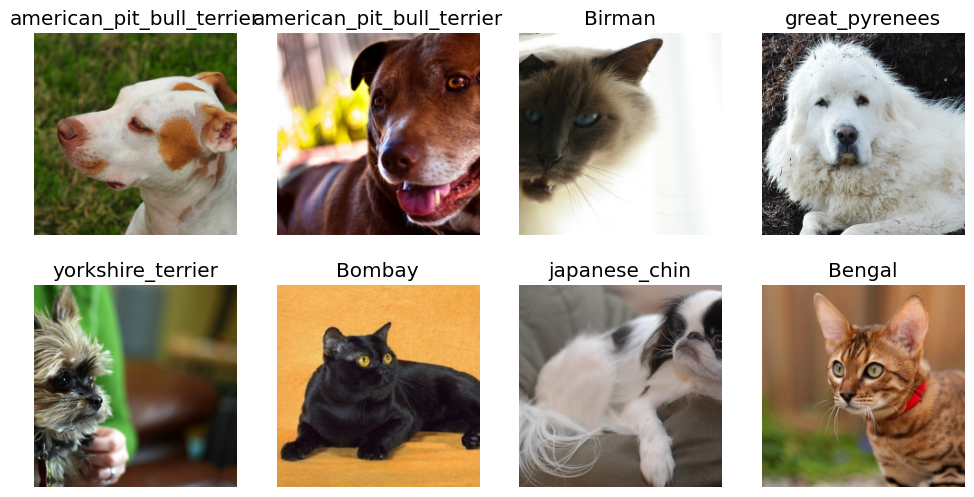

In [39]:
pets = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=using_attr(RegexLabeller(r'(.+)_\d+\.jpg'), 'name'),
    splitter=RandomSplitter(seed=42),
    item_tfms=Resize(460),
    batch_tfms=aug_transforms(min_scale=0.75, size=224)
)
pets.dataloaders(path/'images').show_batch(nrows=2, ncols=4)

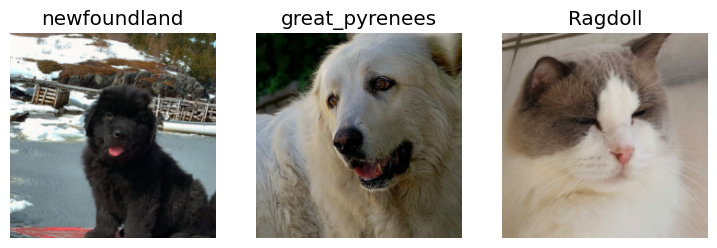

In [45]:
pets.dataloaders(path/'images').train.show_batch(nrows=1, ncols=3)

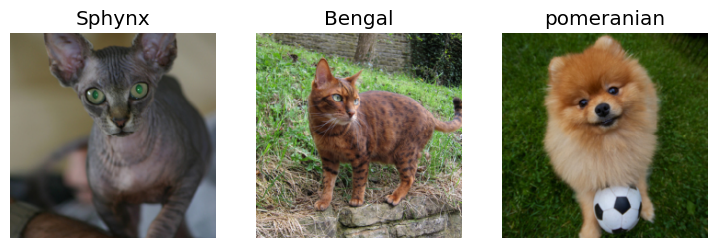

In [44]:
pets.dataloaders(path/'images').valid.show_batch(nrows=1, ncols=3)